# Reusing an NPE after a prior change

This tutorial trains a neural posterior estimator (NPE) once, checks recovery and SBC under its training prior, and then changes the prior **without retraining**. We then compute importance weights, convert the weighted samples to equally weighted samples by sampling-importance resampling, and run the same BayesFlow diagnostics under the new prior.

## A noisy pulse with interpretable parameters

At fixed times $t_1, \ldots, t_J$, our toy observation model is

$$
x_j \mid A, \tau \sim \mathcal{N}\!\left(
A \exp\left[-\frac{(t_j-\tau)^2}{2s^2}\right],
\sigma^2
\right).
$$

The amplitude $A$ changes the pulse height, while the arrival time $\tau$ moves the pulse left or right. The width $s=0.08$ and noise standard deviation $\sigma=0.20$ are known. We first train under the broad independent prior

$$A \sim \mathcal{U}(0.5, 2.0), \qquad \tau \sim \mathcal{U}(0.2, 0.8).$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta as beta_dist

import bayesflow as bf

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.


INFO:bayesflow:Using backend 'jax'


In [2]:
TIMES = np.linspace(0.0, 1.0, 25)
WIDTH = 0.08
NOISE_SD = 0.20
AMPLITUDE_BOUNDS = (0.5, 2.0)
ARRIVAL_BOUNDS = (0.2, 0.8)
PARAMETER_KEYS = ("amplitude", "arrival_time")
LABELS = ["Amplitude", "Arrival time"]


def scale_from_unit_interval(unit_values, bounds):
    lower, upper = bounds
    return lower + (upper - lower) * unit_values


def simulate_pulses(num_simulations, rng, prior):
    if prior == "training":
        amplitude_unit = rng.uniform(size=num_simulations)
        arrival_unit = rng.uniform(size=num_simulations)
    elif prior == "new":
        amplitude_unit = rng.beta(2.0, 5.0, size=num_simulations)
        arrival_unit = rng.beta(5.0, 2.0, size=num_simulations)
    else:
        raise ValueError("prior must be 'training' or 'new'")

    amplitude = scale_from_unit_interval(amplitude_unit, AMPLITUDE_BOUNDS)
    arrival_time = scale_from_unit_interval(arrival_unit, ARRIVAL_BOUNDS)
    mean = amplitude[:, None] * np.exp(
        -0.5 * ((TIMES[None, :] - arrival_time[:, None]) / WIDTH) ** 2
    )

    signal = mean + rng.normal(scale=NOISE_SD, size=mean.shape)

    return {
        "amplitude": amplitude[:, None],
        "arrival_time": arrival_time[:, None],
        "signal": signal.astype(np.float32),
    }

All simulation and resampling randomness comes from local NumPy generators. The training, validation, and diagnostic datasets are independent.

In [3]:
sequences = np.random.SeedSequence(2026).spawn(5)
train_rng, validation_rng, old_test_rng, new_test_rng, resample_rng = [
    np.random.default_rng(sequence) for sequence in sequences
]

train = simulate_pulses(8192, train_rng, prior="training")
validation = simulate_pulses(1024, validation_rng, prior="training")
old_test = simulate_pulses(256, old_test_rng, prior="training")

print({key: value.shape for key, value in train.items()})

{'amplitude': (8192, 1), 'arrival_time': (8192, 1), 'signal': (8192, 25)}


The noiseless means below isolate each parameter's effect. Larger amplitudes make a taller pulse; later arrival times shift the same pulse to the right.

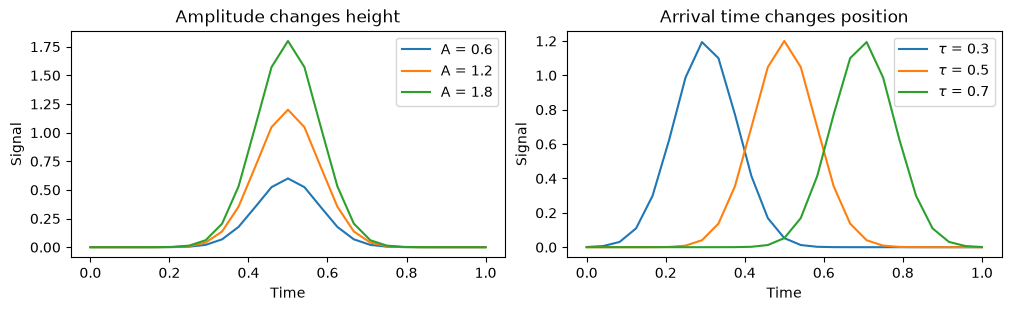

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), layout="constrained")
for amplitude in (0.6, 1.2, 1.8):
    axes[0].plot(
        TIMES,
        amplitude * np.exp(-0.5 * ((TIMES - 0.5) / WIDTH) ** 2),
        label=f"A = {amplitude:.1f}",
    )
for arrival_time in (0.3, 0.5, 0.7):
    axes[1].plot(
        TIMES,
        1.2 * np.exp(-0.5 * ((TIMES - arrival_time) / WIDTH) ** 2),
        label=rf"$\tau$ = {arrival_time:.1f}",
    )
for ax in axes:
    ax.set(xlabel="Time", ylabel="Signal")
    ax.legend()

axes[0].set_title("Amplitude changes height")
axes[1].set_title("Arrival time changes position");

## Train the NPE once

The adapter concatenates $A$ and $\tau$ into the inference variables and uses the 25 signal values as inference conditions. A coupling flow learns $q_\phi(A, \tau \mid x)$ from simulations under the training prior.

In [ ]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .constrain("amplitude", lower=AMPLITUDE_BOUNDS[0], upper=AMPLITUDE_BOUNDS[1])
    .constrain("arrival_time", lower=ARRIVAL_BOUNDS[0], upper=ARRIVAL_BOUNDS[1])
    .concatenate(PARAMETER_KEYS, into="inference_variables")
    .rename("signal", "inference_conditions")
)

workflow = bf.BasicWorkflow(
    adapter=adapter,
    inference_network=bf.networks.CouplingFlow(
        depth=3,
        transform="spline",
        subnet_kwargs={"widths": (64, 64)},
    ),
    standardize="all",
    initial_learning_rate=5e-4,
)

history = workflow.fit_offline(
    train,
    validation_data=validation,
    epochs=200,
    batch_size=512,
    verbose=0,
)
print(f"Final validation loss: {history.history['val_loss'][-1]:.3f}")

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.


INFO:bayesflow:Building on a test batch.


INFO:bayesflow:Training completed in 45.65 seconds.


Final validation loss: -1.051


## Recovery and calibration under the training prior

We draw posterior samples for independent simulations from the same prior used for training. The recovery plot compares posterior medians and credible intervals with ground truth.

In [6]:
old_posterior = workflow.sample(
    conditions={"signal": old_test["signal"]},
    num_samples=1000,
    seed=1001,
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.92 seconds.


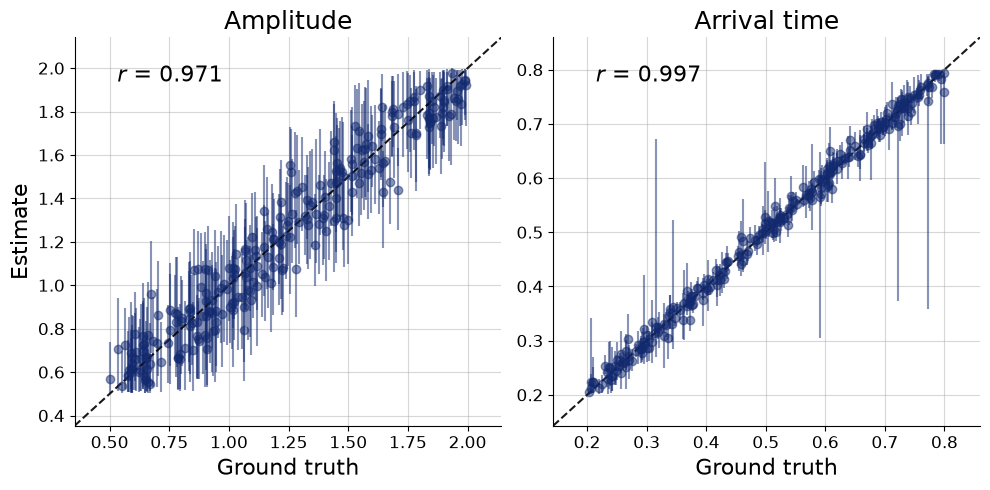

In [7]:
fig = bf.diagnostics.recovery(
    old_posterior, old_test, variable_names=LABELS
)

For simulation-based calibration, the ECDF of posterior ranks should remain inside the simultaneous confidence bands and fluctuate around zero.

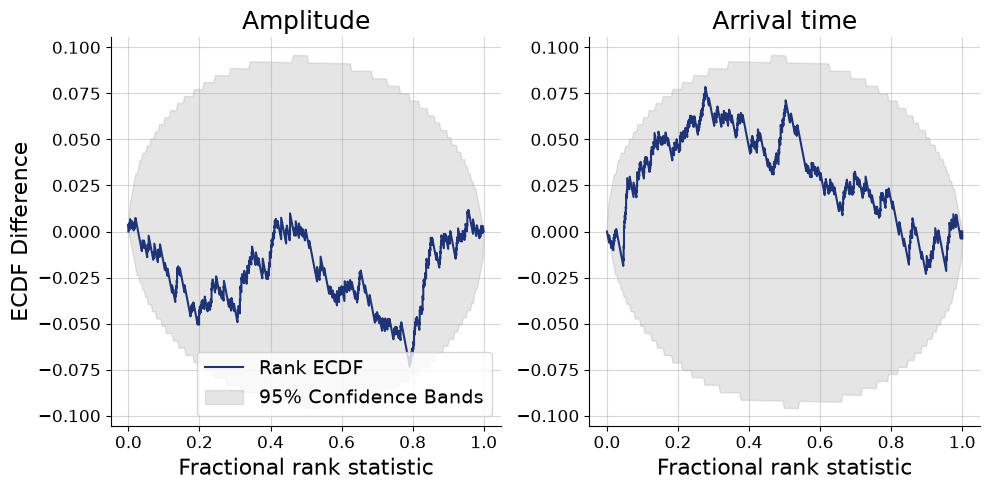

In [8]:
fig = bf.diagnostics.calibration_ecdf(
    old_posterior, old_test, variable_names=LABELS
)

## Change the prior without retraining

Suppose prior knowledge now favors smaller pulses and later arrival times. On the same support, define

$$
\frac{A-0.5}{1.5} \sim \operatorname{Beta}(2,5),
\qquad
\frac{\tau-0.2}{0.6} \sim \operatorname{Beta}(5,2).
$$

Let $p_0(\theta)$ be the training prior, $p_1(\theta)$ the new prior, and $p(x\mid\theta)$ the unchanged likelihood. The NPE approximates the posterior under the training prior,

$$q_\phi(\theta\mid x) \approx p_0(\theta\mid x).$$

The new posterior can be written as

$$
p_1(\theta\mid x)
= \frac{p(x\mid\theta)p_1(\theta)}{p_1(x)}
\propto p_0(\theta\mid x)
\frac{p_1(\theta)}{p_0(\theta)}.
$$

Thus, for NPE draws $\theta^{(s)} \sim q_\phi(\theta\mid x)$, the self-normalized weights are

$$
r_s=\frac{p_1(\theta^{(s)})}{p_0(\theta^{(s)})},
\qquad
\widetilde w_s=\frac{r_s}{\sum_{k=1}^{S}r_k}.
$$

For any posterior quantity $h$, $\mathbb{E}_{p_1}[h(\theta)] \approx \sum_s \widetilde w_s h(\theta^{(s)})$. This requires the new prior to have no support outside the training prior and relies on the NPE accurately approximating $p_0(\theta\mid x)$ wherever the new posterior has mass.

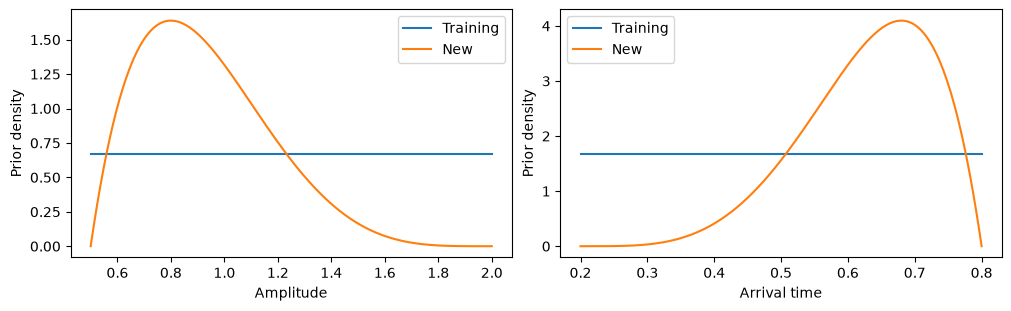

In [9]:
grid = np.linspace(0.0, 1.0, 501)
fig, axes = plt.subplots(1, 2, figsize=(10, 3), layout="constrained")

prior_specs = (
    (axes[0], AMPLITUDE_BOUNDS, (2.0, 5.0), "Amplitude"),
    (axes[1], ARRIVAL_BOUNDS, (5.0, 2.0), "Arrival time"),
)

for ax, bounds, shapes, label in prior_specs:
    values = scale_from_unit_interval(grid, bounds)
    width = bounds[1] - bounds[0]
    ax.plot(values, np.full_like(values, 1.0 / width), label="Training")
    ax.plot(values, beta_dist.pdf(grid, *shapes) / width, label="New")
    ax.set(xlabel=label, ylabel="Prior density")
    ax.legend()

For a valid new-prior calibration check, ground-truth parameters must be drawn from the **new** prior before simulating their data. We pass those data through the already-trained NPE; there is no second call to `fit_offline`. The resulting `base_posterior` contains draws from the NPE approximation to $p_0(\theta\mid x)$, the posterior under the training prior.

In [10]:
new_test = simulate_pulses(256, new_test_rng, prior="new")

base_posterior = workflow.sample(
    conditions={"signal": new_test["signal"]},
    num_samples=1000,
    seed=1002
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.76 seconds.


Because the training prior is uniform, the density-scale factors cancel in $p_1/p_0$. The adapter constrains both parameters to the training-prior bounds, so the ratio is the product of the two beta densities evaluated on the unit interval. We compute it on the log scale for numerical stability.

In [ ]:
def to_unit_interval(values, bounds):
    return (values - bounds[0]) / (bounds[1] - bounds[0])


def normalized_prior_importance_weights(samples):
    amplitude_unit = to_unit_interval(samples["amplitude"][..., 0], AMPLITUDE_BOUNDS)
    arrival_unit = to_unit_interval(samples["arrival_time"][..., 0], ARRIVAL_BOUNDS)

    log_ratio = (
        beta_dist.logpdf(amplitude_unit, 2.0, 5.0)
        + beta_dist.logpdf(arrival_unit, 5.0, 2.0)
    )
    log_ratio -= np.max(log_ratio, axis=1, keepdims=True)
    weights = np.exp(log_ratio)
    weights /= np.sum(weights, axis=1, keepdims=True)

    if not np.isfinite(weights).all():
        raise RuntimeError("Importance weights could not be normalized.")
    return weights


importance_weights = normalized_prior_importance_weights(base_posterior)
effective_sample_size = 1.0 / np.sum(importance_weights**2, axis=1)
print(
    "Importance-sampling ESS (out of 1000): ",
    f"median={np.median(effective_sample_size):.0f}, ",
    f"minimum={np.min(effective_sample_size):.0f}",
)

Importance-sampling ESS (out of 1000):  median=915,  minimum=401


BayesFlow's recovery and calibration functions expect equally weighted posterior draws. The external systematic sampling-importance-resampling step below turns the weighted draws into that form; it is not a second inference model.

In [12]:
def systematic_resample(samples, weights, rng):
    num_datasets, num_samples = weights.shape
    indices = np.empty((num_datasets, num_samples), dtype=np.int64)
    offsets = np.arange(num_samples) / num_samples
    for dataset_index in range(num_datasets):
        positions = offsets + rng.uniform() / num_samples
        cumulative_weights = np.cumsum(weights[dataset_index])
        cumulative_weights[-1] = 1.0
        indices[dataset_index] = np.searchsorted(
            cumulative_weights, positions, side="right"
        )
    return {
        key: np.take_along_axis(values, indices[..., None], axis=1)
        for key, values in samples.items()
    }


new_posterior = systematic_resample(
    base_posterior, importance_weights, resample_rng
)

## Recovery and calibration under the new prior

These are the same two BayesFlow diagnostics as before, now using new-prior test simulations and the importance-resampled posterior.

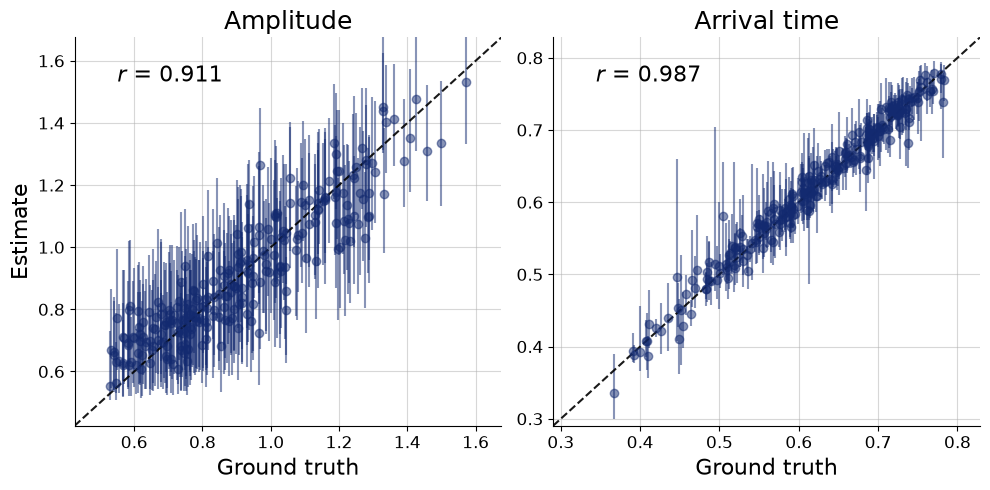

In [13]:
fig = bf.diagnostics.recovery(
    new_posterior, new_test, variable_names=LABELS
)

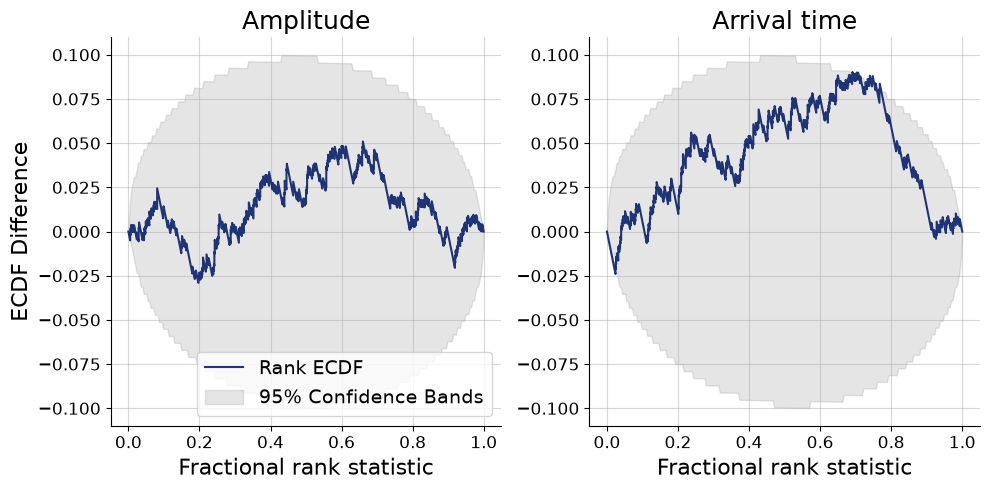

In [14]:
fig = bf.diagnostics.calibration_ecdf(
    new_posterior, new_test, variable_names=LABELS
)

Importance reweighting is useful for a contained, moderate prior shift. It cannot repair an NPE outside its training support, and very uneven weights mean too few effective samples. In either case, simulate from a broader training prior or retrain under the new prior.